In [36]:
from pathlib import Path

import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/WineQT.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [37]:
df.shape

(1143, 13)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [40]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

In [43]:
df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [44]:
df["quality"].value_counts(normalize=True).sort_index()

quality
3    0.005249
4    0.028871
5    0.422572
6    0.404199
7    0.125109
8    0.013998
Name: proportion, dtype: float64

In [45]:
df["quality"].describe()

count    1143.000000
mean        5.657043
std         0.805824
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [46]:
df["quality"].nunique()

6

In [47]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [48]:
binary_target = (df["quality"] >= 7).astype(int)
binary_target.value_counts().sort_index()

quality
0    984
1    159
Name: count, dtype: int64

In [49]:
binary_target.value_counts(normalize=True).sort_index()

quality
0    0.860892
1    0.139108
Name: proportion, dtype: float64

In [50]:
quality_distribution = (
    df["quality"]
    .value_counts()
    .sort_index()
    .rename_axis("quality")
    .reset_index(name="count")
)

quality_distribution["proportion"] = (
    quality_distribution["count"] / quality_distribution["count"].sum()
)

quality_distribution

,quality,count,proportion
0,3,6,0.005249
1,4,33,0.028871
2,5,483,0.422572
3,6,462,0.404199
4,7,143,0.125109
5,8,16,0.013998


In [51]:
binary_distribution = (
    binary_target
    .value_counts()
    .sort_index()
    .rename_axis("is_good_quality")
    .reset_index(name="count")
)

binary_distribution["proportion"] = (
    binary_distribution["count"] / binary_distribution["count"].sum()
)

binary_distribution

,is_good_quality,count,proportion
0,0,984,0.860892
1,1,159,0.139108


In [52]:
TARGET = 'quality'
id_col = 'Id'

feature_columns = [col for col in df.columns if col not in [id_col, TARGET]]
feature_columns 

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [53]:
len(feature_columns), len(df.columns)

(11, 13)

In [54]:
quality_distribution = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis('quality')
    .reset_index(name='count')
)

quality_distribution['proportion'] = (
    quality_distribution['count'] / quality_distribution['count'].sum()
)

quality_distribution

,quality,count,proportion
0,3,6,0.005249
1,4,33,0.028871
2,5,483,0.422572
3,6,462,0.404199
4,7,143,0.125109
5,8,16,0.013998


In [56]:
import matplotlib.pyplot as plt

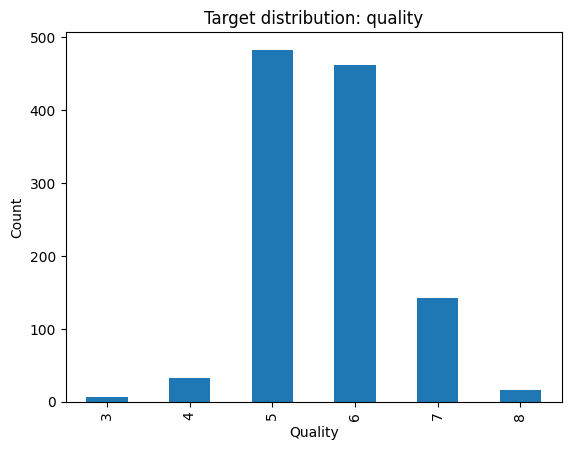

In [57]:
quality_distribution.plot(
    x="quality",
    y="count",
    kind="bar",
    legend=False,
    title="Target distribution: quality"
)

plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

In [58]:
df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


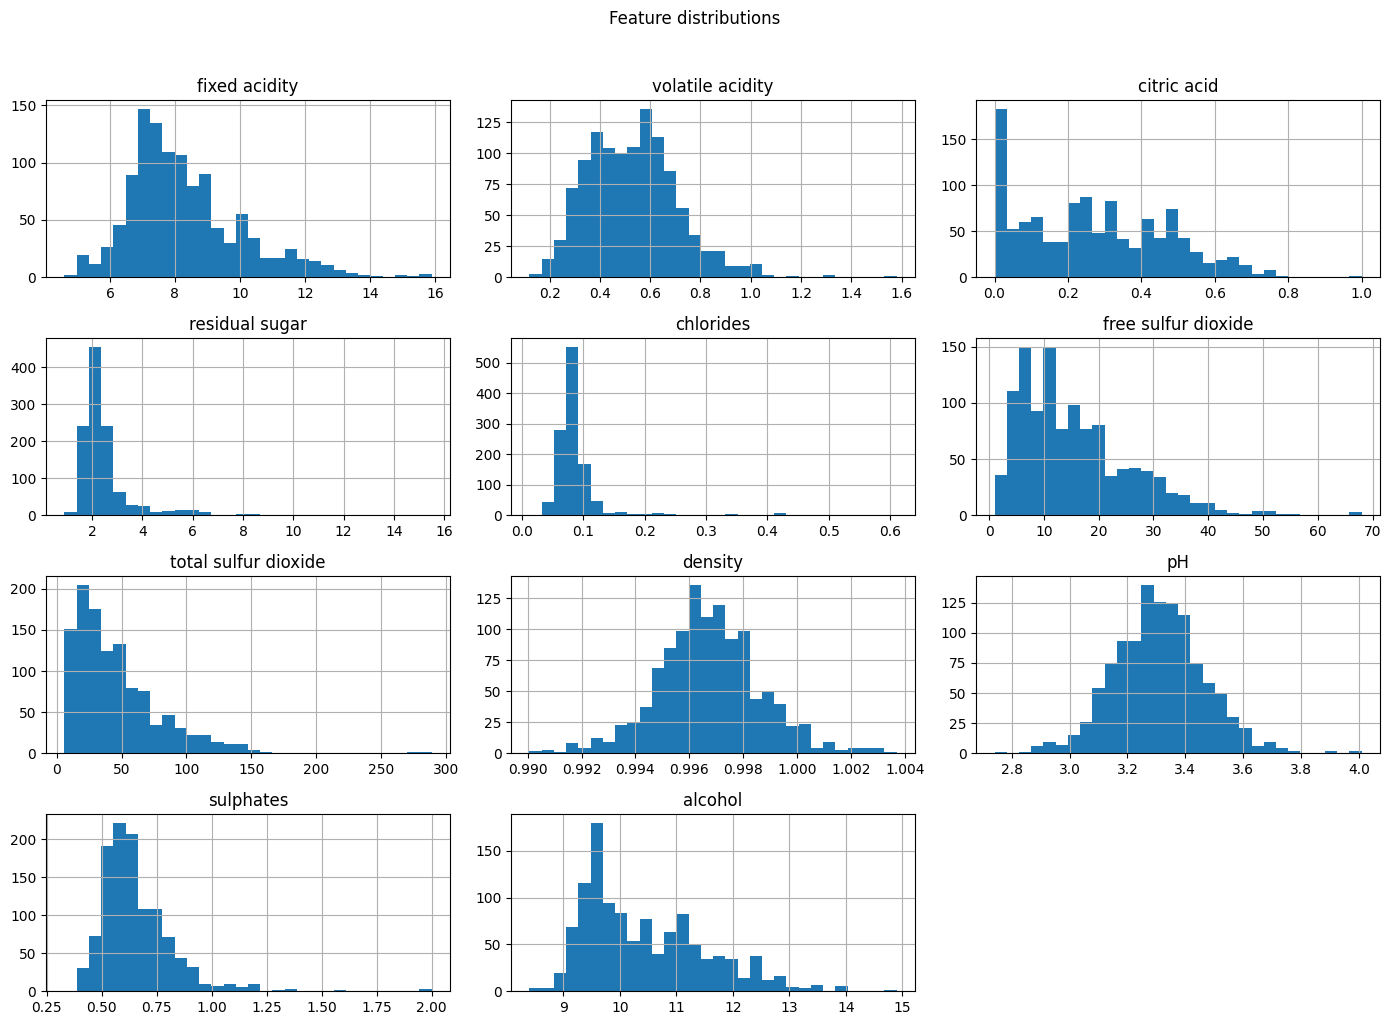

In [59]:
df[feature_columns].hist(figsize=(14, 10), bins=30)

plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.show()

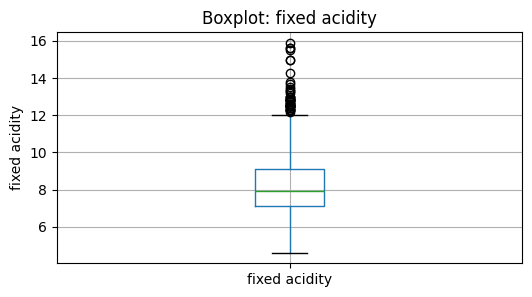

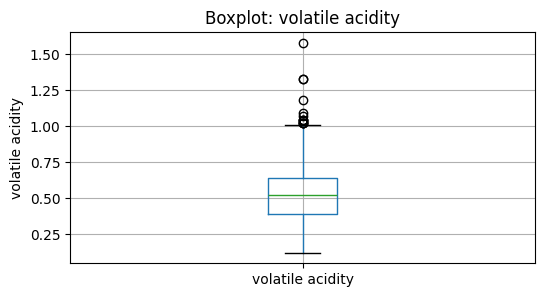

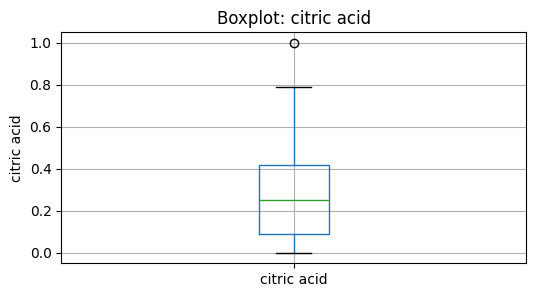

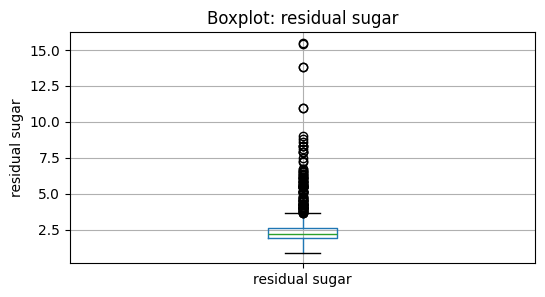

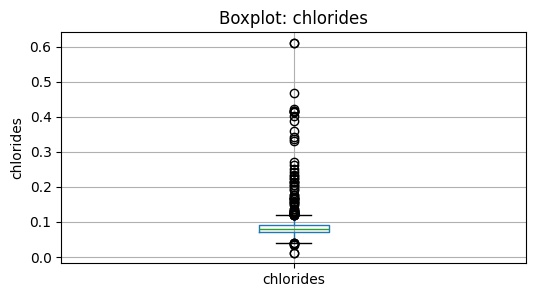

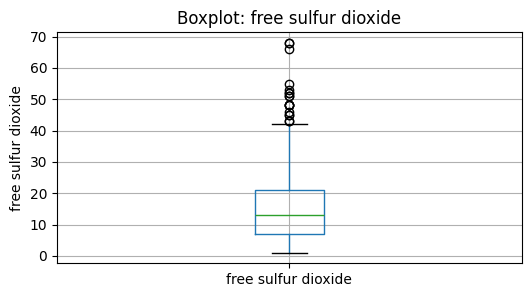

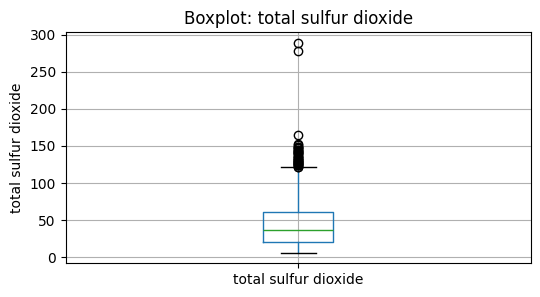

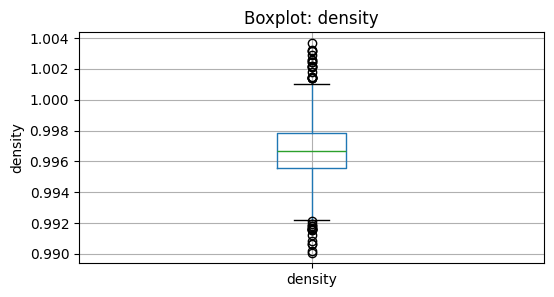

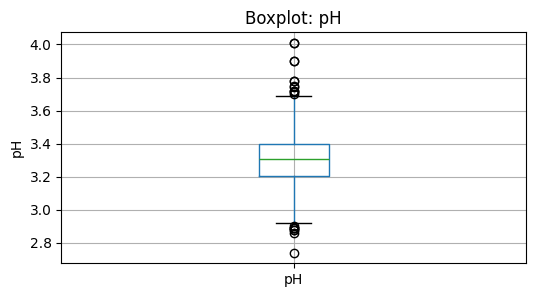

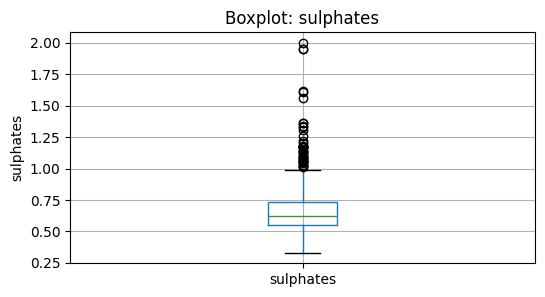

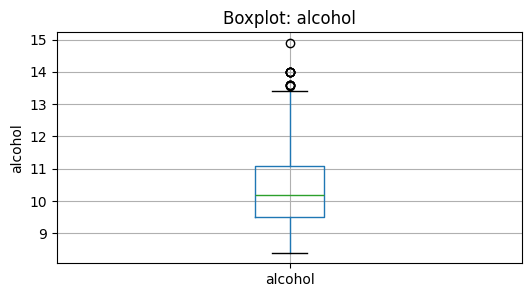

In [60]:
for col in feature_columns:
    plt.figure(figsize=(6, 3))
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.show()

In [61]:
correlations_with_target = (
    df[feature_columns + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

correlations_with_target

alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

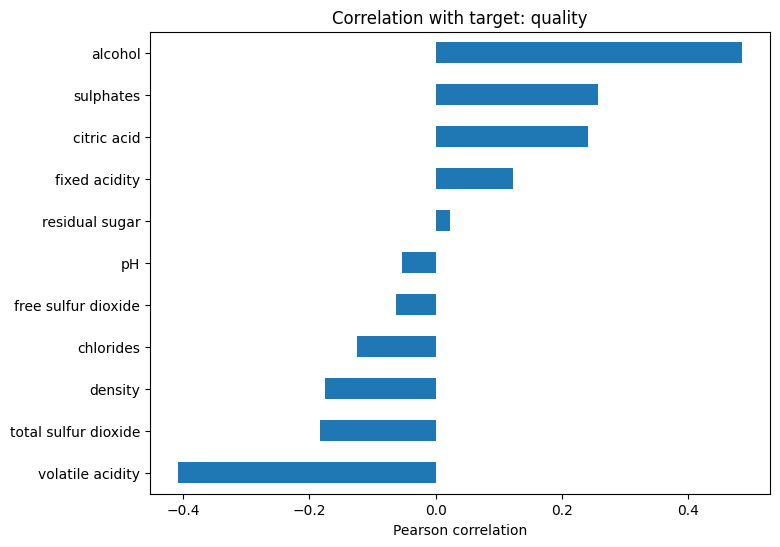

In [62]:
correlations_with_target.sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Correlation with target: quality"
)

plt.xlabel("Pearson correlation")
plt.show()

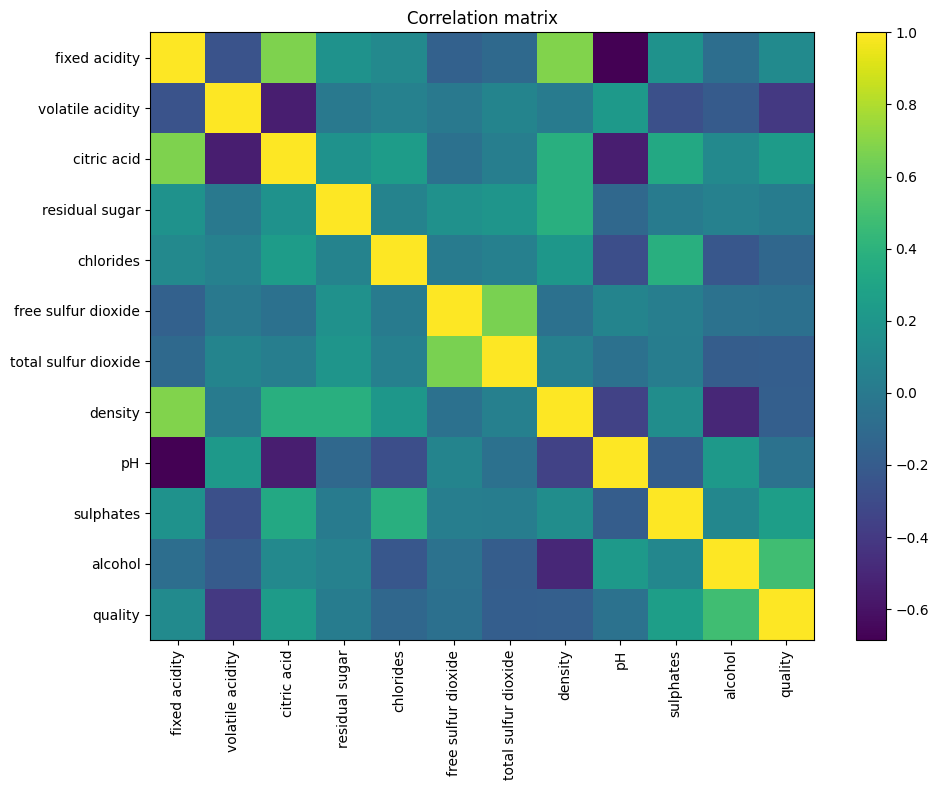

In [63]:
corr_matrix = df[feature_columns + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


In [64]:
mean_features_by_quality = df.groupby(TARGET)[feature_columns].mean()

mean_features_by_quality

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.450000,0.897500,0.211667,2.666667,0.105333,8.166667,24.500000,0.997682,3.361667,0.550000,9.691667
4,7.809091,0.700000,0.165758,2.566667,0.094788,14.848485,40.606061,0.996669,3.391212,0.637879,10.260606
5,8.161077,0.585280,0.240124,2.540476,0.091770,16.612836,55.299172,0.997073,3.302091,0.613375,9.902277
6,8.317749,0.504957,0.263680,2.444805,0.085281,15.215368,39.941558,0.996610,3.323788,0.676537,10.655339
7,8.851049,0.393671,0.386573,2.760140,0.075217,14.538462,37.489510,0.996071,3.287133,0.743566,11.482634
8,8.806250,0.410000,0.432500,2.643750,0.070187,11.062500,29.375000,0.995553,3.240625,0.766250,11.937500


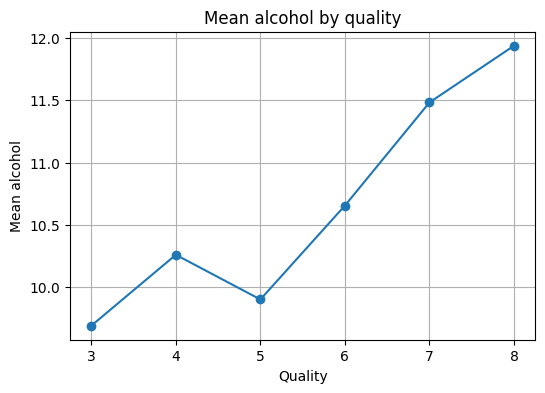

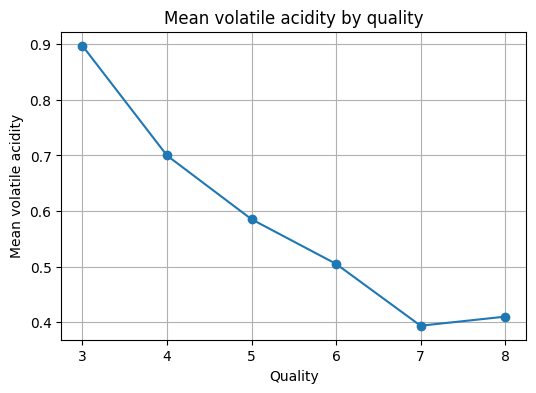

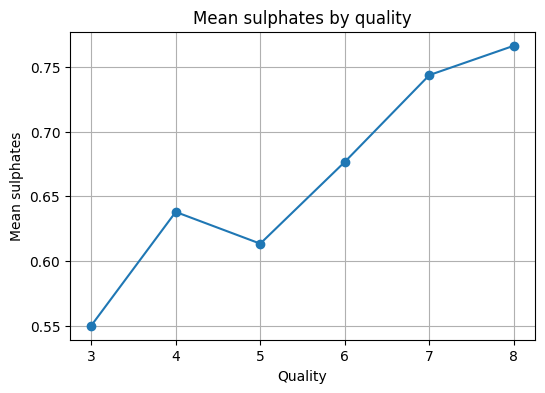

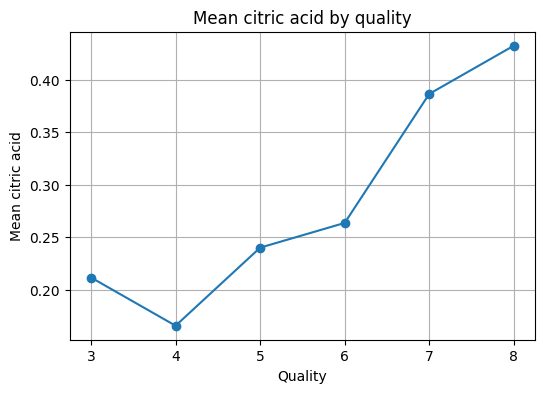

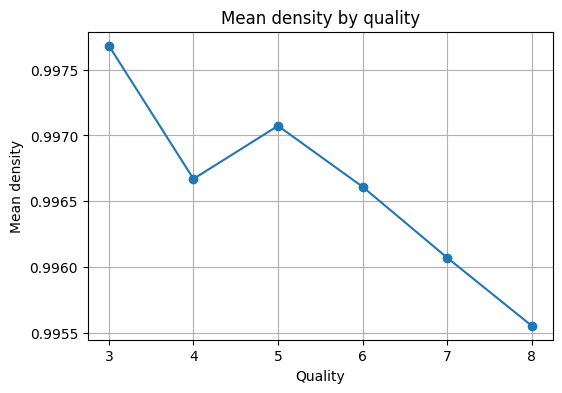

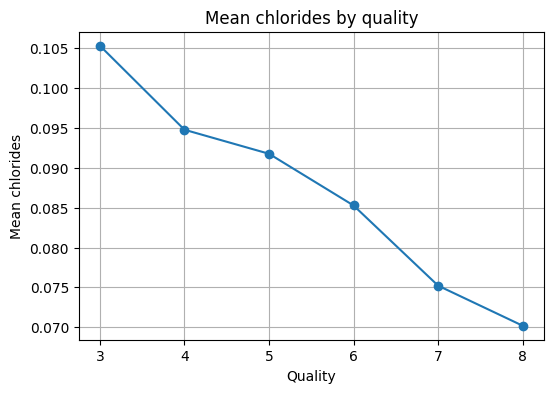

In [65]:
important_features_to_plot = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "density",
    "chlorides",
]

for col in important_features_to_plot:
    plt.figure(figsize=(6, 4))
    mean_features_by_quality[col].plot(marker="o")
    plt.title(f"Mean {col} by quality")
    plt.xlabel("Quality")
    plt.ylabel(f"Mean {col}")
    plt.grid(True)
    plt.show()

In [66]:
min_max_table = pd.DataFrame({
    "min": df[feature_columns].min(),
    "max": df[feature_columns].max(),
    "mean": df[feature_columns].mean(),
    "median": df[feature_columns].median(),
    "std": df[feature_columns].std(),
})

min_max_table

,min,max,mean,median,std
fixed acidity,4.60000,15.90000,8.311111,7.90000,1.747595
volatile acidity,0.12000,1.58000,0.531339,0.52000,0.179633
citric acid,0.00000,1.00000,0.268364,0.25000,0.196686
residual sugar,0.90000,15.50000,2.532152,2.20000,1.355917
chlorides,0.01200,0.61100,0.086933,0.07900,0.047267
free sulfur dioxide,1.00000,68.00000,15.615486,13.00000,10.250486
total sulfur dioxide,6.00000,289.00000,45.914698,37.00000,32.782130
density,0.99007,1.00369,0.996730,0.99668,0.001925
pH,2.74000,4.01000,3.311015,3.31000,0.156664
sulphates,0.33000,2.00000,0.657708,0.62000,0.170399


In [67]:
zero_counts = (df[feature_columns] == 0).sum().sort_values(ascending=False)

zero_counts

citric acid             99
fixed acidity            0
volatile acidity         0
residual sugar           0
chlorides                0
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       0
sulphates                0
alcohol                  0
dtype: int64

In [68]:
outlier_summary = []

for col in feature_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_proportion = outlier_count / len(df)
    
    outlier_summary.append({
        "feature": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_proportion": outlier_proportion,
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "outlier_count",
    ascending=False
)

outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_proportion
3,residual sugar,0.850000,3.650000,110,0.096238
4,chlorides,0.040000,0.120000,77,0.067367
0,fixed acidity,4.100000,12.100000,44,0.038495
9,sulphates,0.280000,1.000000,43,0.037620
6,total sulfur dioxide,-39.000000,121.000000,40,0.034996
7,density,0.992157,1.001257,36,0.031496
8,pH,2.912500,3.692500,20,0.017498
5,free sulfur dioxide,-14.000000,42.000000,18,0.015748
1,volatile acidity,0.021250,1.011250,14,0.012248
10,alcohol,7.100000,13.500000,12,0.010499


## EDA conclusions

### Dataset structure

- The dataset contains 1143 rows and 13 columns.
- The target column is `quality`.
- The first iteration task is regression.
- The `Id` column is a technical identifier and should be excluded from the feature matrix.
- Planned feature matrix contains 11 numerical feature columns.

### Missing values and duplicates

- No missing values were found.
- No duplicated rows were found.

### Target distribution

- The target `quality` is ordinal.
- Observed quality values are 3, 4, 5, 6, 7, and 8.
- Most observations are concentrated in quality classes 5 and 6.
- Extreme quality values are rare:
  - quality 3: 6 observations;
  - quality 4: 33 observations;
  - quality 8: 16 observations.
- This confirms that multiclass classification would suffer from class imbalance, especially for rare classes.
- For the first iteration, regression remains the selected framing.

### Feature distributions

- Several features are right-skewed:
  - `fixed acidity`;
  - `volatile acidity`;
  - `residual sugar`;
  - `chlorides`;
  - `free sulfur dioxide`;
  - `total sulfur dioxide`;
  - `sulphates`;
  - `alcohol`.
- Some features have visible outliers according to boxplots and IQR analysis:
  - `residual sugar`;
  - `chlorides`;
  - `fixed acidity`;
  - `sulphates`;
  - `total sulfur dioxide`;
  - `density`;
  - `pH`;
  - `free sulfur dioxide`.
- Feature scales differ substantially. For example:
  - `density` is close to 1.0;
  - `chlorides` is usually below 0.1;
  - `total sulfur dioxide` ranges up to 289.
- This may matter later for scale-sensitive models such as KNN, linear models with regularization, SVR, and gradient-based models.

### Correlations with target

The strongest positive correlations with `quality` are:

- `alcohol`: approximately 0.485;
- `sulphates`: approximately 0.258;
- `citric acid`: approximately 0.241.

The strongest negative correlations with `quality` are:

- `volatile acidity`: approximately -0.407;
- `total sulfur dioxide`: approximately -0.183;
- `density`: approximately -0.175;
- `chlorides`: approximately -0.124.

Most correlations are weak to moderate. The clearest linear relationships are:

- higher `alcohol` tends to be associated with higher quality;
- higher `volatile acidity` tends to be associated with lower quality.

This suggests that wine quality is probably not explained by one feature alone. Interactions and nonlinear effects may matter, so later it will be useful to compare linear models with tree-based models and possibly distance-based models.

### Suspicious values / outliers

- Zero values were found only in `citric acid`.
- These zero values do not look automatically suspicious in this dataset, because zero citric acid can be chemically plausible.
- No missing-value proxies like in the Pima Diabetes dataset were identified.
- IQR outliers were detected, especially in:
  - `residual sugar`: 110 observations;
  - `chlorides`: 77 observations;
  - `fixed acidity`: 44 observations;
  - `sulphates`: 43 observations;
  - `total sulfur dioxide`: 40 observations.
- These outliers should not be removed at this stage.
- Outlier handling, if needed, should be tested later inside a proper train/CV workflow.

### Modeling implications for later stages

- `Id` must be excluded from `X`.
- Target is `quality`.
- First iteration task is regression.
- Baseline metrics should include MAE and RMSE.
- Because the target is ordinal and concentrated around 5 and 6, MAE will be especially interpretable.
- Scaling may be useful for some models later because feature scales differ.
- Outliers may affect linear models and distance-based models.
- Tree-based models may be more robust to monotonic transformations and feature scaling.
- No fitted preprocessing should be applied before train/test split.
- The holdout test set must be used only once for final evaluation.